In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs

import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display, clear_output

# Introduction

## Cluster plots

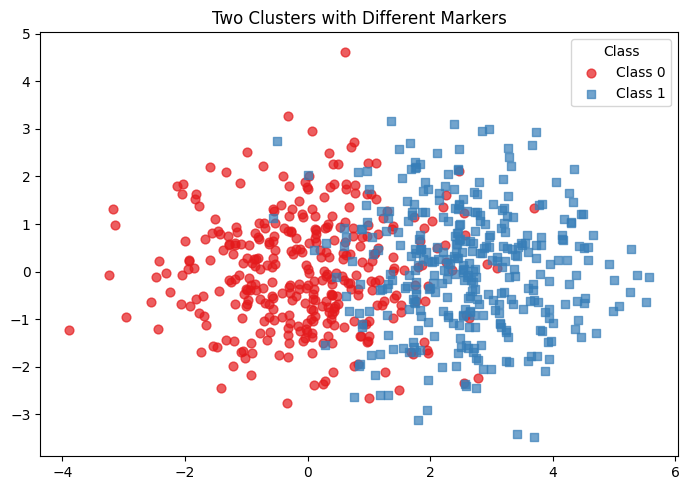

In [2]:
palette = sns.color_palette('Set1', n_colors=5)
def plot_clusters(n_samples=1000, centers=3, cluster_std=1.2, markers={0: 'o', 1: 's'}, colors=None, title='Clusters'):
    # Generate data
    X, y = make_blobs(
        n_samples=n_samples, 
        centers=centers,
        cluster_std=cluster_std, 
        random_state=42
    )
    df = pd.DataFrame(X, columns=['feature1', 'feature2'])
    df['label'] = y

    plt.figure(figsize=(7, 5))
    markers = markers
    # Use provided colors or default palette
    if colors is None:
        palette = sns.color_palette('Set1', n_colors=len(np.unique(y)))
        colors = {label: palette[label] for label in np.unique(y)}
    else:
        # If colors is a list, convert to dict
        if isinstance(colors, list):
            colors = {label: colors[label] for label in np.unique(y)}
    for label in np.unique(y):
        subset = df[df['label'] == label]
        plt.scatter(
            subset['feature1'], subset['feature2'],
            marker=markers.get(label, 'o'),
            color=colors.get(label, 'gray'),
            alpha=0.7, s=40, label=f'Class {label}'
        )
    plt.xlabel('')
    plt.ylabel('')
    plt.title(title)
    plt.legend(title='Class')
    plt.tight_layout()
    plt.show()

plot_clusters(
    n_samples=700,
    centers=[(0,0), (2.5,0)],
    colors=[palette[0], palette[1]],  # Pass the palette directly
    markers={0: 'o', 1: 's'},
    title='Two Clusters with Different Markers'
)

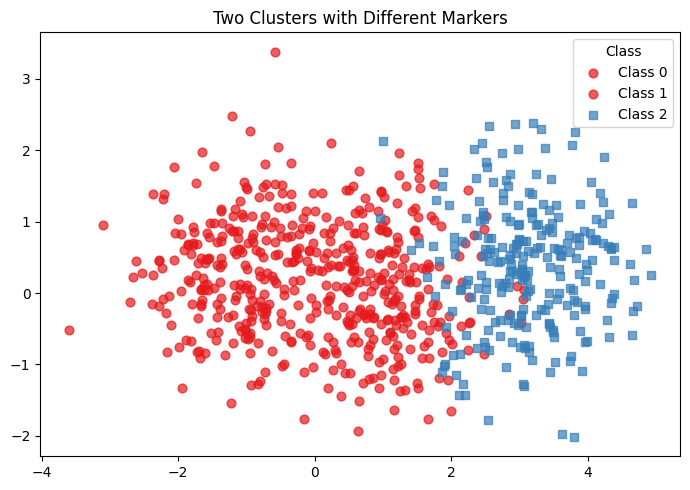

In [3]:
plot_clusters(
    n_samples=750,
    centers=[(-1,0.3), (1,0), (3,0.3)],
    cluster_std=0.8,
    colors=[palette[0], palette[0], palette[1]],  # Pass the palette directly
    markers={0: 'o', 1: 'o', 2: 's'},
    title='Two Clusters with Different Markers'
)

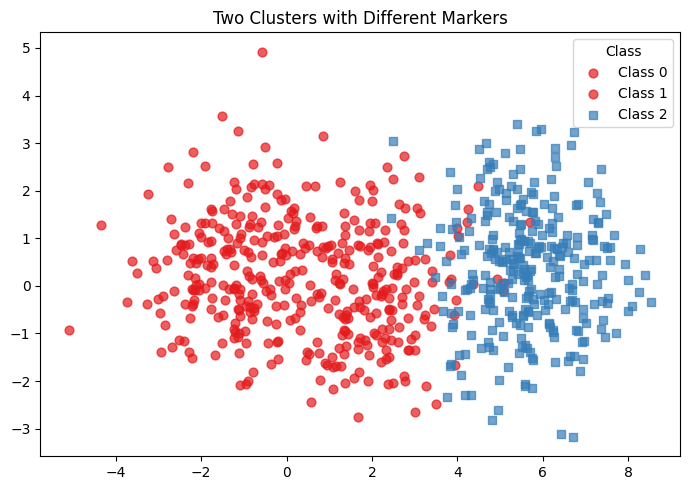

In [4]:
plot_clusters(
    n_samples=[200,200,300],
    centers=[(-1.2,0.3), (2,0), (5.5,0.3)],
    cluster_std=1.2,
    colors=[palette[0], palette[0], palette[1]],  # Pass the palette directly
    markers={0: 'o', 1: 'o', 2: 's'},
    title='Two Clusters with Different Markers'
)

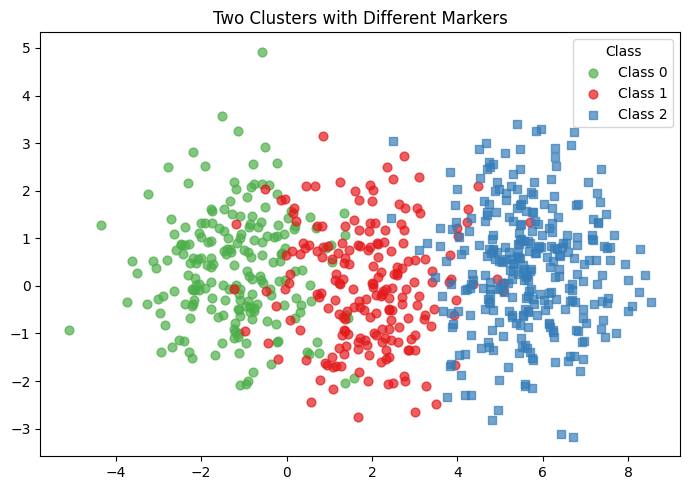

In [5]:
plot_clusters(
    n_samples=[200,200,300],
    centers=[(-1.2,0.3), (2,0), (5.5,0.3)],
    cluster_std=1.2,
    colors=[palette[2], palette[0], palette[1]],  # Pass the palette directly
    markers={0: 'o', 1: 'o', 2: 's'},
    title='Two Clusters with Different Markers'
)

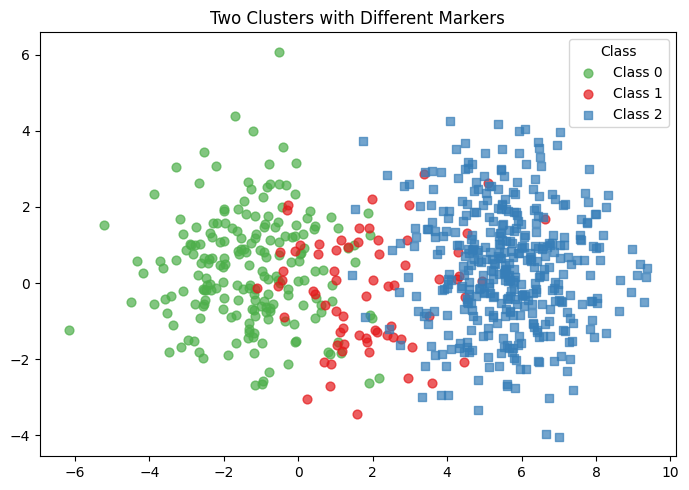

In [6]:
plot_clusters(
    n_samples=[200,70,400],
    centers=[(-1.3,0.3), (2,0), (5.5,0.3)],
    cluster_std=1.5,
    colors=[palette[2], palette[0], palette[1]],  # Pass the palette directly
    markers={0: 'o', 1: 'o', 2: 's'},
    title='Two Clusters with Different Markers'
)

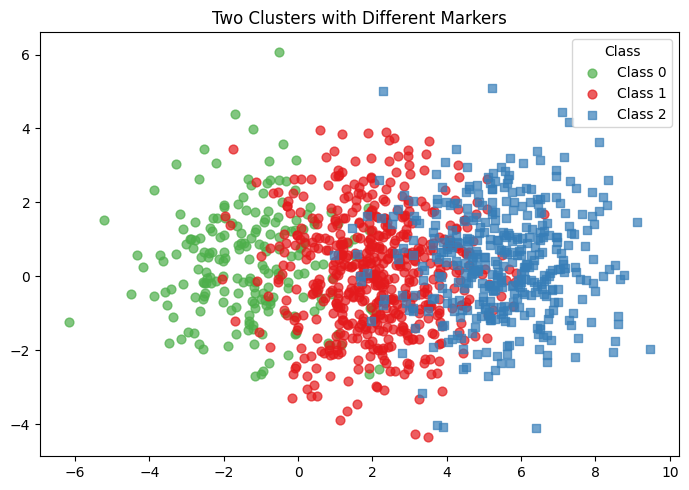

In [7]:
plot_clusters(
    n_samples=[200,550,400],
    centers=[(-1.3,0.3), (2,0), (5.5,0.3)],
    cluster_std=1.5,
    colors=[palette[2], palette[0], palette[1]],  # Pass the palette directly
    markers={0: 'o', 1: 'o', 2: 's'},
    title='Two Clusters with Different Markers'
)

## Score density plots

In [8]:
def MoSS(n, alpha, m):
    p_score = np.random.uniform(size=int(n * alpha)) ** m
    n_score = 1 - (np.random.uniform(size=int(round(n * (1 - alpha), 0))) ** m)
    scores = np.column_stack((np.concatenate((p_score, n_score)), np.concatenate((np.ones(len(p_score)), np.full(len(n_score), 0)))))
    # pdb.set_trace()
    return scores

MoSS(1000, 0.5, 0.3)

array([[0.68795674, 1.        ],
       [0.88266576, 1.        ],
       [0.56973981, 1.        ],
       ...,
       [0.24285182, 0.        ],
       [0.00345484, 0.        ],
       [0.22788918, 0.        ]], shape=(1000, 2))

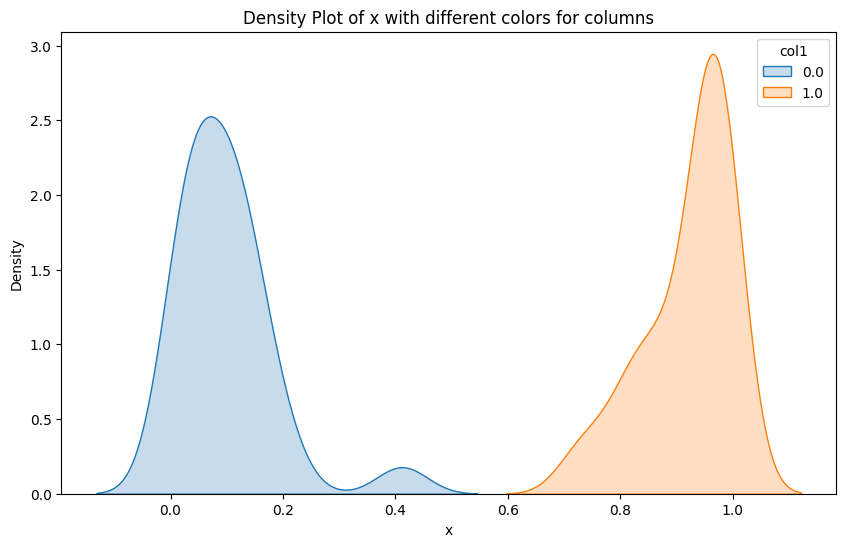

In [9]:
x=MoSS(50, 0.5, 0.1)
x = pd.DataFrame(x)
x.columns = ['x', 'col1']

def plot_density(x):
    # Create the density plot
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=x, x='x', hue='col1', fill=True)

    plt.title('Density Plot of x with different colors for columns')
    plt.xlabel('x')
    plt.ylabel('Density')
    plt.show()

plot_density(x)


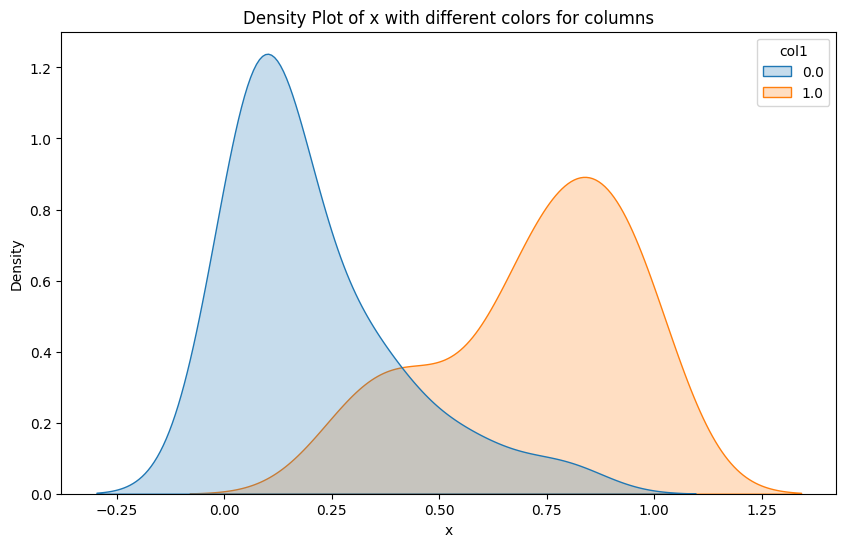

In [10]:
x=MoSS(50, 0.5, 0.4)
x = pd.DataFrame(x)
x.columns = ['x', 'col1']

plot_density(x)

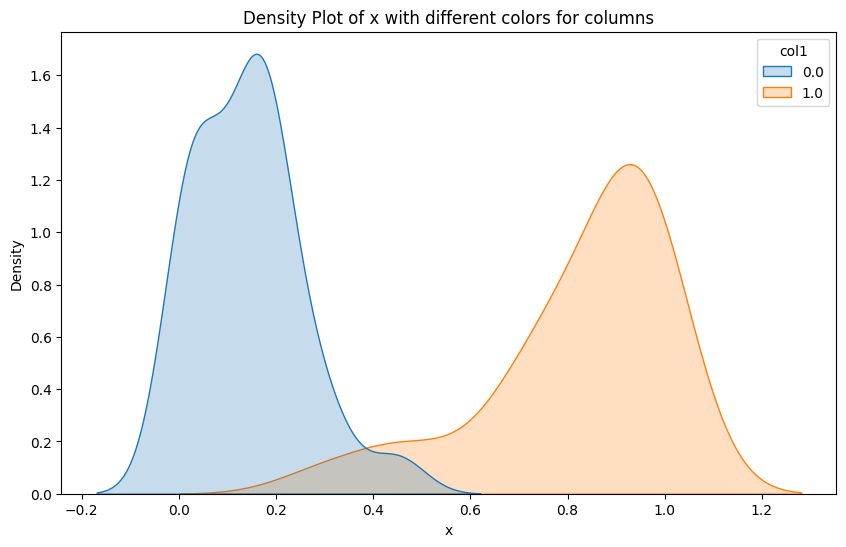

In [11]:
x=MoSS(50, 0.5, 0.2)
x = pd.DataFrame(x)
x.columns = ['x', 'col1']

def plot_density(x):
    # Create the density plot
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=x, x='x', hue='col1', fill=True)

    plt.title('Density Plot of x with different colors for columns')
    plt.xlabel('x')
    plt.ylabel('Density')
    plt.show()

plot_density(x)


# Results

In [12]:
results_path = './results_paper/'

## Synthetic

In [13]:
df_syn = pd.read_csv(results_path + 'results_syn_t50.csv')

# fix HDy values in P_1 and AE columns
# import ast
# mask = df_syn['Qnt'].isin(['HDy', 'HDySyn'])
# df_syn.loc[mask, 'P_1'] = df_syn.loc[mask, 'P_1'].apply(lambda x: ast.literal_eval(x.replace(' ', ','))[0])
# df_syn.loc[mask, 'AE'] = abs(df_syn.loc[mask, 'P_1'] - df_syn.loc[mask, 'R_1'])

df_syn

,MFtr,MFte,R_1,P_1,AE,Distance,Qnt
0,0.05,0.05,0.0,0.00,0.00,NaN,CC
1,0.05,0.05,0.0,0.00,0.00,NaN,ACC
2,0.05,0.05,0.0,0.00,0.00,topsoe,ACCSyn-TS
3,0.05,0.05,0.0,0.00,0.00,NaN,T50
4,0.05,0.05,0.0,0.00,0.00,topsoe,T50Syn-TS
...,...,...,...,...,...,...,...
8021415,0.95,0.95,1.0,0.56,0.44,topsoe,DySyn-TS
8021416,0.95,0.95,1.0,0.00,1.00,NaN,SMM
8021417,0.95,0.95,1.0,0.90,0.10,topsoe,SMMSyn-TS
8021418,0.95,0.95,1.0,1.00,0.00,NaN,HDy


In [107]:
df_syn['AE'] = df_syn['AE'].astype(float)

In [109]:
import plotly.graph_objects as go

# Select classic and synthetic quantifiers
classic_methods = ['ACC', 'X', 'MAX', 'MS', 'PACC', 'T50']
synthetic_methods = ['ACCSyn-TS', 'XSyn-TS', 'MAXSyn-TS', 'MSSyn-TS', 'PACCSyn-TS', 'T50Syn-TS']

# Filter df_syn for the selected quantifiers
classic_data = df_syn[df_syn['Qnt'].isin(classic_methods)]
synthetic_data = df_syn[df_syn['Qnt'].isin(synthetic_methods)]
print(classic_data)
print(synthetic_data)

# Create box plots
fig = go.Figure()

fig.add_trace(go.Box(
    y=classic_data['AE'],
    name='Classic',
    marker_color='tab:blue',
    boxmean=True
))

fig.add_trace(go.Box(
    y=synthetic_data['AE'],
    name='Synthetic',
    marker_color='tab:orange',
    boxmean=True
))

fig.update_layout(
    title='AE Distribution: Synthetic vs Classic (df_syn)',
    yaxis_title='AE',
    xaxis_title='Type',
    boxmode='group'
)

fig.show()

         MFtr  MFte  R_1    P_1    AE Distance   Qnt
1        0.05  0.05  0.0  0.000  0.00      NaN   ACC
3        0.05  0.05  0.0  0.000  0.00      NaN   T50
6        0.05  0.05  0.0  0.046  0.05      NaN  PACC
8        0.05  0.05  0.0  0.000  0.00      NaN     X
10       0.05  0.05  0.0  0.000  0.00      NaN   MAX
...       ...   ...  ...    ...   ...      ...   ...
8021401  0.95  0.95  1.0  1.000  0.00      NaN   T50
8021404  0.95  0.95  1.0  1.000  0.00      NaN  PACC
8021406  0.95  0.95  1.0  1.000  0.00      NaN     X
8021408  0.95  0.95  1.0  0.000  1.00      NaN   MAX
8021410  0.95  0.95  1.0  1.000  0.00      NaN    MS

[2187660 rows x 7 columns]
         MFtr  MFte  R_1    P_1    AE Distance         Qnt
2        0.05  0.05  0.0  0.000  0.00   topsoe   ACCSyn-TS
4        0.05  0.05  0.0  0.000  0.00   topsoe   T50Syn-TS
7        0.05  0.05  0.0  0.045  0.04   topsoe  PACCSyn-TS
9        0.05  0.05  0.0  0.000  0.00   topsoe     XSyn-TS
11       0.05  0.05  0.0  0.000  0.00   t

ValueError: 
    Invalid value of type 'builtins.str' received for the 'color' property of box.marker
        Received value: 'tab:blue'

    The 'color' property is a color and may be specified as:
      - A hex string (e.g. '#ff0000')
      - An rgb/rgba string (e.g. 'rgb(255,0,0)')
      - An hsl/hsla string (e.g. 'hsl(0,100%,50%)')
      - An hsv/hsva string (e.g. 'hsv(0,100%,100%)')
      - A named CSS color:
            aliceblue, antiquewhite, aqua, aquamarine, azure,
            beige, bisque, black, blanchedalmond, blue,
            blueviolet, brown, burlywood, cadetblue,
            chartreuse, chocolate, coral, cornflowerblue,
            cornsilk, crimson, cyan, darkblue, darkcyan,
            darkgoldenrod, darkgray, darkgrey, darkgreen,
            darkkhaki, darkmagenta, darkolivegreen, darkorange,
            darkorchid, darkred, darksalmon, darkseagreen,
            darkslateblue, darkslategray, darkslategrey,
            darkturquoise, darkviolet, deeppink, deepskybl

In [89]:
def mae_error_mftr_plotly(df_syn):
    grouped = df_syn.groupby(['Qnt', 'MFte', 'MFtr']).agg({'AE': 'mean'}).reset_index()

    mftr_dropdown = widgets.Dropdown(
        options=grouped['MFtr'].unique(),
        description='MFtr:'
    )

    mftr_dropdown.value = grouped['MFtr'].unique()[0]

    def update_plot(change):
        selected_mftr = mftr_dropdown.value
        filtered_data = grouped[grouped['MFtr'] == selected_mftr]

        fig = go.Figure()
        for qnt_val in filtered_data['Qnt'].unique():
            if qnt_val in ['CC', 'ACC', 'PCC', 'PACC', 'PCCSyn-TS', 'PACCSyn-TS']:
                qnt_data = filtered_data[filtered_data['Qnt'] == qnt_val]
                # Show ACC and ACCSyn by default, others as legendonly
                visible = True if qnt_val in ['ACC', 'ACCSyn-TS'] else 'legendonly'
                fig.add_trace(go.Scatter(
                    x=qnt_data['MFte'],
                    y=qnt_data['AE'],
                    mode='lines+markers',
                    name=qnt_val,
                    # visible=visible
                ))

        fig.update_layout(title=f'MAE vs MFte for MFtr = {selected_mftr}',
                        xaxis_title='MFte',
                        yaxis_title='MAE')

        clear_output(wait=True)
        display(fig)
        display(mftr_dropdown)

    mftr_dropdown.observe(update_plot, names='value')
    display(mftr_dropdown)
    update_plot(None)
mae_error_mftr_plotly(df_syn)

Dropdown(description='MFtr:', options=(np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2), n…

In [16]:
df_syn

,MFtr,MFte,R_1,P_1,AE,Distance,Qnt
0,0.05,0.05,0.0,0.00,0.00,NaN,CC
1,0.05,0.05,0.0,0.00,0.00,NaN,ACC
2,0.05,0.05,0.0,0.00,0.00,topsoe,ACCSyn-TS
3,0.05,0.05,0.0,0.00,0.00,NaN,T50
4,0.05,0.05,0.0,0.00,0.00,topsoe,T50Syn-TS
...,...,...,...,...,...,...,...
8021415,0.95,0.95,1.0,0.56,0.44,topsoe,DySyn-TS
8021416,0.95,0.95,1.0,0.00,1.00,NaN,SMM
8021417,0.95,0.95,1.0,0.90,0.10,topsoe,SMMSyn-TS
8021418,0.95,0.95,1.0,1.00,0.00,NaN,HDy


In [17]:
grouped = df_syn.groupby(['Qnt', 'MFte', 'MFtr']).agg({'AE': 'mean'}).reset_index()
grouped

,Qnt,MFte,MFtr,AE
0,ACC,0.05,0.05,0.000000
1,ACC,0.05,0.10,0.000000
2,ACC,0.05,0.15,0.003267
3,ACC,0.05,0.20,0.016337
4,ACC,0.05,0.25,0.029307
...,...,...,...,...
7937,XSyn-TS,0.95,0.75,0.289030
7938,XSyn-TS,0.95,0.80,0.287376
7939,XSyn-TS,0.95,0.85,0.292307
7940,XSyn-TS,0.95,0.90,0.299881


Dropdown(description='MFtr:', index=13, options=(np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float…

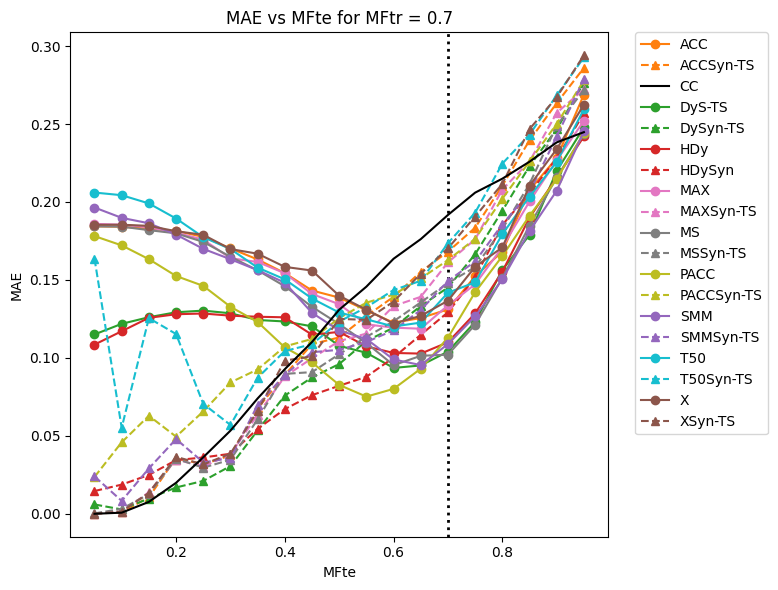

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib

# Define a color map so that each method and its Syn variant share the same color
method_pairs = [
    ('CC', 'CCSyn-TS'),
    ('ACC', 'ACCSyn-TS'),
    ('DyS-TS', 'DySyn-TS'),
    ('HDy', 'HDySyn'),
    ('SMM', 'SMMSyn-TS'),
    ('X', 'XSyn-TS'),
    ('MAX', 'MAXSyn-TS'),
    ('MS', 'MSSyn-TS'),
    ('PACC', 'PACCSyn-TS'),
    ('T50', 'T50Syn-TS'),
]

# Use matplotlib's tab10 color palette for distinct colors
base_colors = matplotlib.cm.get_cmap('tab10', len(method_pairs))

color_map = {}
for idx, (classic, syn) in enumerate(method_pairs):
    color = base_colors(idx)
    color_map[classic] = color
    color_map[syn] = color

def mae_error_mftr_matplot(df_syn):
    grouped = df_syn.groupby(['Qnt', 'MFte', 'MFtr']).agg({'AE': 'mean'}).reset_index()

    mftr_dropdown = widgets.Dropdown(
        options=sorted(grouped['MFtr'].unique()),
        description='MFtr:'
    )

    mftr_dropdown.value = grouped['MFtr'].unique()[0]

    thr_qnt = ['CC', 'ACC', 'ACCSyn-TS', 'X', 'XSyn-TS', 'MAX', 'MAXSyn-TS', 'MS', 'MSSyn-TS', 'PACC', 'PACCSyn-TS', 'T50', 'T50Syn-TS']
    distr_qnt = ['CC', 'DyS-TS', 'DySyn-TS', 'HDy', 'HDySyn', 'SMM', 'SMMSyn-TS']
    qnt = thr_qnt + distr_qnt

    def update_plot(change):
        selected_mftr = mftr_dropdown.value
        filtered_data = grouped[grouped['MFtr'] == selected_mftr]

        plt.figure(figsize=(10, 6))
        
        for qnt_val in filtered_data['Qnt'].unique():
            qnt_data = filtered_data[filtered_data['Qnt'] == qnt_val]
            if 'Syn' in qnt_val:
                marker_style = '^'
                line_style = '--'
                z = 1
            else:
                if qnt_val == 'CC':
                    marker_style = None
                    line_style = '-'
                    z = 10  # Draw CC on top
                else:
                    marker_style = 'o'
                    line_style = '-'
                    z = 1

            if qnt_val in qnt:
                if qnt_val in color_map:
                    if qnt_val == 'CC':
                        plt.plot(
                            qnt_data['MFte'], qnt_data['AE'],
                            marker=marker_style, linestyle=line_style,
                            label=qnt_val, color='black', zorder=z
                        )
                    else:
                        plt.plot(
                            qnt_data['MFte'], qnt_data['AE'],
                            marker=marker_style, linestyle=line_style,
                            label=qnt_val, color=color_map[qnt_val], zorder=z
                        )

        plt.title(f'MAE vs MFte for MFtr = {selected_mftr}')
        plt.xlabel('MFte')
        plt.ylabel('MAE')
        # Place the legend outside the plot box
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
        plt.tight_layout(rect=[0, 0, 0.8, 1])  # Make room for the legend
        plt.axvline(selected_mftr, color='black', linestyle=':', linewidth=2, zorder=0)

        clear_output(wait=True)
        display(mftr_dropdown)
        plt.savefig('mae_vs_mftr_plot.pdf', format='pdf', bbox_inches='tight')
        plt.show()

    mftr_dropdown.observe(update_plot, names='value')
    display(mftr_dropdown)
    update_plot(None)
mae_error_mftr_matplot(df_syn)

Dropdown(description='MFtr:', index=13, options=(np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float…

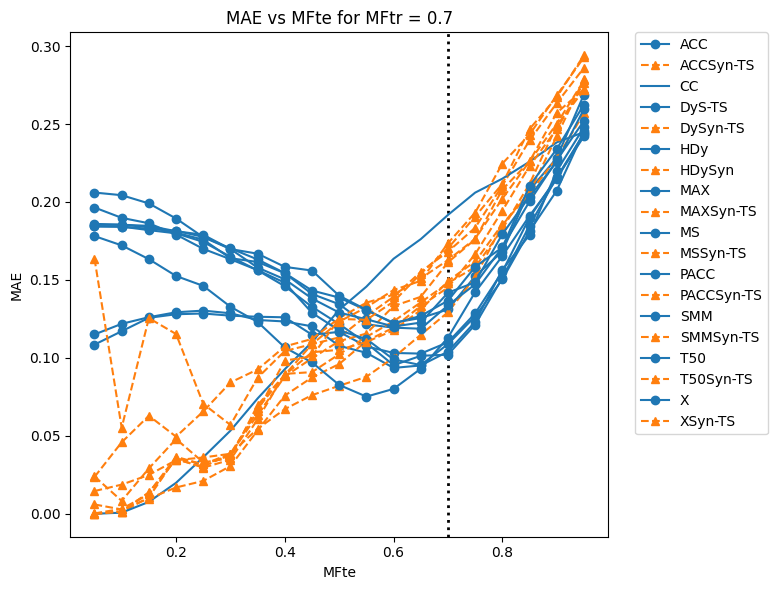

In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib

# Define method pairs (classic, syn)
method_pairs = [
    ('CC', 'CCSyn-TS'),
    ('ACC', 'ACCSyn-TS'),
    ('DyS-TS', 'DySyn-TS'),
    ('HDy', 'HDySyn'),
    ('SMM', 'SMMSyn-TS'),
    ('X', 'XSyn-TS'),
    ('MAX', 'MAXSyn-TS'),
    ('MS', 'MSSyn-TS'),
    ('PACC', 'PACCSyn-TS'),
    ('T50', 'T50Syn-TS'),
]

# Assign only two colors: one for classic, one for syn
classic_color = 'tab:blue'
syn_color = 'tab:orange'
color_map = {}
for classic, syn in method_pairs:
    color_map[classic] = classic_color
    color_map[syn] = syn_color

def mae_error_mftr_matplot(df_syn):
    grouped = df_syn.groupby(['Qnt', 'MFte', 'MFtr']).agg({'AE': 'mean'}).reset_index()

    mftr_dropdown = widgets.Dropdown(
        options=sorted(grouped['MFtr'].unique()),
        description='MFtr:'
    )

    mftr_dropdown.value = grouped['MFtr'].unique()[0]

    thr_qnt = ['CC', 'ACC', 'ACCSyn-TS', 'X', 'XSyn-TS', 'MAX', 'MAXSyn-TS', 'MS', 'MSSyn-TS', 'PACC', 'PACCSyn-TS', 'T50', 'T50Syn-TS']
    distr_qnt = ['CC', 'DyS-TS', 'DySyn-TS', 'HDy', 'HDySyn', 'SMM', 'SMMSyn-TS']
    qnt = thr_qnt + distr_qnt

    def update_plot(change):
        selected_mftr = mftr_dropdown.value
        filtered_data = grouped[grouped['MFtr'] == selected_mftr]

        plt.figure(figsize=(10, 6))
        
        for qnt_val in filtered_data['Qnt'].unique():
            qnt_data = filtered_data[filtered_data['Qnt'] == qnt_val]
            if 'Syn' in qnt_val:
                marker_style = '^'
                line_style = '--'
                color = syn_color
            else:
                if qnt_val == 'CC':
                    marker_style = None
                    line_style = '-'
                else:
                    marker_style = 'o'
                    line_style = '-'
                color = classic_color

            if qnt_val in qnt:
                plt.plot(
                    qnt_data['MFte'],
                    qnt_data['AE'],
                    marker=marker_style,
                    linestyle=line_style,
                    label=qnt_val,
                    color=color
                )

        plt.title(f'MAE vs MFte for MFtr = {selected_mftr}')
        plt.xlabel('MFte')
        plt.ylabel('MAE')
        # Place the legend outside the plot box
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
        plt.tight_layout(rect=[0, 0, 0.8, 1])  # Make room for the legend
        plt.axvline(selected_mftr, color='black', linestyle=':', linewidth=2, zorder=0)

        clear_output(wait=True)
        display(mftr_dropdown)
        plt.show()

    mftr_dropdown.observe(update_plot, names='value')
    display(mftr_dropdown)
    update_plot(None)
mae_error_mftr_matplot(df_syn)

## Real

In [30]:
df_real = pd.read_csv(results_path + 'lequa2025_results_datasets.csv')
df_real.rename({'error': 'AE', 'quantifier': 'Qnt', 'harderDistr': 'H'}, axis=1, inplace=True)
df_real

,actual+,actual-,predict+,predict-,AE,testSize,Qnt,H,dataset
0,0.01,0.99,0.010000,0.990000,0.00,100,CC,0.0,Avila
1,0.01,0.99,0.000000,1.000000,0.01,100,HDy-LP,0.0,Avila
2,0.01,0.99,0.020000,0.980000,0.01,100,HDySyn,0.0,Avila
3,0.01,0.99,0.000000,1.000000,0.01,100,ACC,0.0,Avila
4,0.01,0.99,0.010020,0.989980,0.00,100,ACCSyn,0.0,Avila
...,...,...,...,...,...,...,...,...,...
1151395,1.00,0.00,1.000000,0.000000,0.00,100,T50Syn,1.0,Walking
1151396,1.00,0.00,0.999996,0.000004,0.00,100,DyS-TS,1.0,Walking
1151397,1.00,0.00,0.980000,0.020000,0.02,100,DySyn-TS,1.0,Walking
1151398,1.00,0.00,1.000000,0.000000,0.00,100,SMM,1.0,Walking


### Boxplot per dataset

In [ ]:
def plot_ae_boxplots_by_dataset(df_real):
    datasets = list(df_real['dataset'].unique())
    datasets.insert(0, 'All')
    dropdown = widgets.Dropdown(
        options=datasets,
        description='Dataset:'
    )

    def update_plot(change):
        selected_dataset = dropdown.value
        if selected_dataset == 'All':
            filtered = df_real
        else:
            filtered = df_real[df_real['dataset'] == selected_dataset]
        fig = go.Figure()
        for qnt in filtered['Qnt'].unique():
            qnt_data = filtered[filtered['Qnt'] == qnt]['AE']
            fig.add_trace(go.Box(
                y=qnt_data,
                name=qnt,
                width=0.5
            ))
        fig.update_layout(
            title=f'AE Boxplots per Qnt for {selected_dataset}',
            yaxis_title='AE',
            xaxis_title='Qnt',
            boxmode='group',
        )
        clear_output(wait=True)
        display(fig)
        display(dropdown)

    dropdown.observe(update_plot, names='value')
    display(dropdown)
    update_plot(None)

plot_ae_boxplots_by_dataset(df_real)

Dropdown(description='Dataset:', index=5, options=('All', 'Avila', 'Chess game', 'Covertype', 'Dermatology', '…

### Boxplot ranking per dataset (MAE)

In [31]:
grouped_real = df_real.groupby(['dataset', 'Qnt']).agg({'AE': 'mean'}).reset_index()
grouped_real[grouped_real['dataset'] == 'Avila'].sort_values('AE', ascending=True)

,dataset,Qnt,AE
4,Avila,DySyn-TS,0.044251
18,Avila,XSyn,0.045988
1,Avila,ACCSyn,0.046368
6,Avila,HDySyn,0.048727
8,Avila,MAXSyn,0.050341
11,Avila,PACC,0.053943
2,Avila,CC,0.056123
17,Avila,X,0.059689
0,Avila,ACC,0.064671
3,Avila,DyS-TS,0.064840


In [35]:
pivot_real = grouped_real.pivot(index='dataset', columns='Qnt', values='AE').reset_index()
# pivot_real.drop(columns='dataset', inplace=True)
# pivot_real.T.to_csv('mae_datasets_real.csv')
pivot_real.T

,0,1,2,3,4,5,6,7,8,9,10,11
Qnt,,,,,,,,,,,,
dataset,Avila,Chess game,Covertype,Dermatology,HAR,Land-use,Mfeat,Mosquitoes,Nursery,Phishing URL,Satimage,Walking
ACC,0.064671,0.052246,0.058909,0.002133,0.026463,0.08404,0.057844,0.059685,0.027131,0.026321,0.090135,0.066152
ACCSyn,0.046368,0.030505,0.105333,0.002248,0.017111,0.048269,0.042164,0.045374,0.027184,0.018422,0.033549,0.083931
CC,0.056123,0.045471,0.097968,0.002133,0.017176,0.061091,0.052125,0.06221,0.022424,0.018352,0.034095,0.098293
DyS-TS,0.06484,0.035414,0.074743,0.002329,0.016432,0.065156,0.037945,0.040366,0.020174,0.014295,0.03457,0.070095
DySyn-TS,0.044251,0.029806,0.112719,0.010117,0.012851,0.038109,0.036665,0.047527,0.027046,0.012604,0.017093,0.074339
HDy-LP,0.079386,0.04765,0.089352,0.00796,0.038289,0.101667,0.039002,0.05498,0.030693,0.01701,0.064483,0.083121
HDySyn,0.048727,0.038812,0.100562,0.05022,0.026481,0.037786,0.034721,0.042208,0.049501,0.024913,0.038398,0.05561
MAX,0.069707,0.046194,0.070079,0.002143,0.019994,0.084642,0.047978,0.053725,0.025281,0.018291,0.050844,0.073295


In [25]:
mean_ranking = pivot_real.rank(axis=1)
mean_ranking_sorted = mean_ranking.mean(axis=0).sort_values().index
mean_ranking = mean_ranking[mean_ranking_sorted]
mean_ranking

TypeError: '<' not supported between instances of 'str' and 'float'

In [33]:
sample = mean_ranking
margin_left = 0.05
margin_right= 0.99
margin_top = 0.99
margin_bottom = .23
plt_width = 38
plt_heigth = 18
plot_rotation = 75
axis_font_size = 50
labels_size = 60

with sns.axes_style("whitegrid"), sns.color_palette('Spectral', mean_ranking.shape[1]):
    plt.figure(figsize=(plt_width,plt_heigth))
    plt.subplots_adjust(left=margin_left, bottom=margin_bottom, right=margin_right, top=margin_top)
    ax=sns.boxplot(data=sample)
    plt.xticks(rotation = plot_rotation, fontsize = axis_font_size)
    plt.yticks(fontsize = axis_font_size)
    ax.set_xlabel("Quantifiers",fontsize=labels_size)
    ax.set_ylabel("Ranking MAE",fontsize=labels_size)

plt.show()

NameError: name 'mean_ranking' is not defined

### Histogram victories

In [61]:
# For each dataset, count how many times ACCSyn AE is less than ACC AE in df_real
def victories_count_df(df_real):
    mae = df_real.groupby(['dataset', 'Qnt']).agg({'AE': 'mean'}).reset_index()
    datasets = mae['dataset'].unique()
    # Only select quantifiers that are Syn variants (ending with 'Syn' or 'Syn-TS')
    syn_qnts = [q for q in mae['Qnt'].unique() if q.endswith('Syn') or q.endswith('Syn-TS')]
    counts_dict = {}
    print(syn_qnts)

    for syn_qnt in syn_qnts:
        if syn_qnt == 'DySyn-TS':
            qnt = 'DyS-TS'
        elif syn_qnt == 'HDySyn':
            qnt = 'HDy-LP'
        else:
            qnt = syn_qnt.replace('Syn', '')

        counts = []
        for dataset in datasets:
            df_subset = mae[mae['dataset'] == dataset]
            syn_ae = df_subset[df_subset['Qnt'] == syn_qnt]['AE'].values
            qnt_ae = df_subset[df_subset['Qnt'] == qnt]['AE'].values
            # If both exist, compare, else set np.nan
            if len(syn_ae) > 0 and len(qnt_ae) > 0:
                count = int(syn_ae[0] < qnt_ae[0])
            else:
                count = np.nan
            counts.append(count)
        counts_dict[syn_qnt] = counts

    return pd.DataFrame(counts_dict, index=datasets)

victories_df = victories_count_df(df_real)
victories_df

['ACCSyn', 'DySyn-TS', 'HDySyn', 'MAXSyn', 'MSSyn', 'PACCSyn', 'SMMSyn', 'T50Syn', 'XSyn']


,ACCSyn,DySyn-TS,HDySyn,MAXSyn,MSSyn,PACCSyn,SMMSyn,T50Syn,XSyn
Avila,1,1,1,1,1,0,1,1,1
Chess game,1,1,1,1,1,0,1,1,1
Covertype,0,0,0,0,0,0,0,0,0
Dermatology,0,0,0,0,0,0,0,0,1
HAR,1,1,1,1,1,0,1,1,1
Land-use,1,1,1,1,1,0,1,1,1
Mfeat,1,1,1,1,0,0,0,1,1
Mosquitoes,1,0,1,1,1,0,1,1,1
Nursery,0,0,0,0,1,0,1,0,0
Phishing URL,1,1,0,0,1,0,1,0,1


In [62]:
# For each Syn column, create a non-Syn column with inverted values
for col in victories_df.columns:
    
    if col == 'DySyn-TS':
        nonsyn_col = 'DyS-TS'
    elif col == 'HDySyn':
        nonsyn_col = 'HDy-LP'
    else:
        nonsyn_col = col.replace('Syn', '')
    
    victories_df[nonsyn_col] = 1 - victories_df[col]

victories_df

,ACCSyn,DySyn-TS,HDySyn,MAXSyn,MSSyn,PACCSyn,SMMSyn,T50Syn,XSyn,ACC,DyS-TS,HDy-LP,MAX,MS,PACC,SMM,T50,X
Avila,1,1,1,1,1,0,1,1,1,0,0,0,0,0,1,0,0,0
Chess game,1,1,1,1,1,0,1,1,1,0,0,0,0,0,1,0,0,0
Covertype,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1
Dermatology,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1,0
HAR,1,1,1,1,1,0,1,1,1,0,0,0,0,0,1,0,0,0
Land-use,1,1,1,1,1,0,1,1,1,0,0,0,0,0,1,0,0,0
Mfeat,1,1,1,1,0,0,0,1,1,0,0,0,0,1,1,1,0,0
Mosquitoes,1,0,1,1,1,0,1,1,1,0,1,0,0,0,1,0,0,0
Nursery,0,0,0,0,1,0,1,0,0,1,1,1,1,0,1,0,1,1
Phishing URL,1,1,0,0,1,0,1,0,1,0,0,1,1,0,1,0,1,0


In [63]:
victories_df_sum = victories_df.sum(axis=0).to_frame().T
victories_df_sum

,ACCSyn,DySyn-TS,HDySyn,MAXSyn,MSSyn,PACCSyn,SMMSyn,T50Syn,XSyn,ACC,DyS-TS,HDy-LP,MAX,MS,PACC,SMM,T50,X
0,8,7,8,7,8,1,8,7,9,4,5,4,5,4,11,4,5,3


['ACC', 'DyS-TS', 'HDy-LP', 'MAX', 'MS', 'PACC', 'SMM', 'T50', 'X']
[np.int64(8), np.int64(7), np.int64(8), np.int64(7), np.int64(8), np.int64(1), np.int64(8), np.int64(7), np.int64(9)]
[np.int64(4), np.int64(5), np.int64(4), np.int64(5), np.int64(4), np.int64(11), np.int64(4), np.int64(5), np.int64(3)]


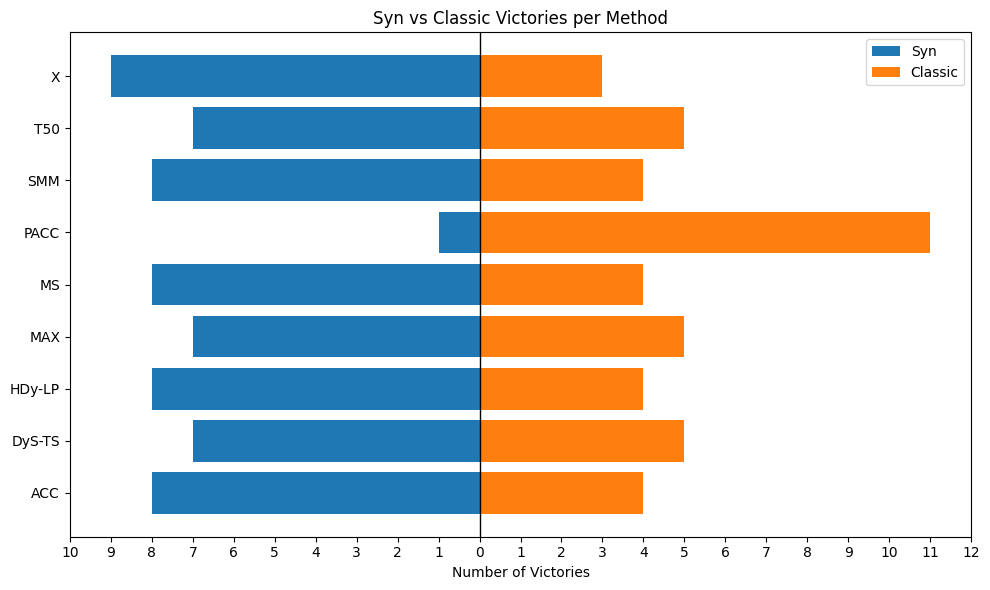

In [84]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MultipleLocator

# Get method names (without 'Syn'), as a flat list
methods = list(victories_df_sum.columns[9:18])

# Syn and Classic victories
syn_victories = [victories_df_sum[col].values[0] for col in victories_df_sum.columns[:9]]
classic_victories = [victories_df_sum[col].values[0] for col in victories_df_sum.columns[9:18]]
print(methods)
print(syn_victories)
print(classic_victories)

fig, ax = plt.subplots(figsize=(10, 6))
ax.xaxis.set_major_locator(MultipleLocator(1))

def abs_tick(x, pos):
    return str(int(abs(x)))

ax.xaxis.set_major_formatter(FuncFormatter(abs_tick))

y = range(len(methods))

# Plot Syn victories (left, negative direction)
ax.barh(y, [-v for v in syn_victories], color='tab:blue', label='Syn', align='center')
# Plot Classic victories (right, positive direction)
ax.barh(y, classic_victories, color='tab:orange', label='Classic', align='center')

# Draw vertical line in the middle
ax.axvline(0, color='black', linewidth=1)

# Method names as y-ticks
ax.set_yticks(y)
ax.set_yticklabels(methods)

ax.set_xlabel('Number of Victories')
ax.set_title('Syn vs Classic Victories per Method')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

### Statistical analysis

In [ ]:
def ae_dataset(df, dataset):
    df = df[df['dataset'] == dataset]
    result = pd.DataFrame(columns=df['Qnt'].unique())

    for qnt in df['Qnt'].unique():
        qnt_data = df[df['Qnt'] == qnt]['AE'].values
        result[qnt] = qnt_data

    return result

In [ ]:
ae_datasets = []
for dataset in df_real['dataset'].unique():
    result = ae_dataset(df_real, dataset)
    ae_datasets.append({'dataset': dataset, 'data': result})

In [ ]:
avila = ae_datasets[0]['data']
avila

,CC,HDy-LP,HDySyn,ACC,ACCSyn,X,XSyn,MAX,MAXSyn,MS,MSSyn,PACC,PACCSyn,T50,T50Syn,DyS-TS,DySyn-TS,SMM,SMMSyn
0,0.00,0.01,0.01,0.01,0.00,0.01,0.00,0.01,0.00,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.00,0.01,0.01
1,0.00,0.01,0.00,0.01,0.00,0.01,0.00,0.01,0.00,0.01,0.01,0.01,0.02,0.01,0.01,0.01,0.01,0.01,0.01
2,0.01,0.01,0.00,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.02,0.01,0.01,0.01,0.01,0.01,0.01
3,0.00,0.01,0.00,0.01,0.00,0.01,0.00,0.01,0.00,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.00,0.01,0.01
4,0.00,0.01,0.00,0.01,0.00,0.01,0.00,0.01,0.00,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5045,0.06,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.16,0.00,0.02,0.00,0.00,0.00,0.00
5046,0.15,0.00,0.01,0.00,0.07,0.00,0.06,0.00,0.10,0.00,0.02,0.04,0.05,0.00,0.07,0.00,0.03,0.00,0.05
5047,0.15,0.00,0.01,0.00,0.07,0.00,0.08,0.00,0.09,0.00,0.01,0.02,0.18,0.00,0.00,0.00,0.02,0.00,0.01
5048,0.07,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.16,0.00,0.00,0.00,0.00,0.00,0.01


In [ ]:
# still needs to check if it is a normal distribution with Shapiro-Wilk test

from scipy.stats import ttest_rel

paired_columns = [
    ['ACC', 'ACCSyn'],
    ['X', 'XSyn'],
    ['MAX', 'MAXSyn'],
    ['MS', 'MSSyn'],
    ['PACC', 'PACCSyn'],
    ['T50', 'T50Syn']
]

def t_student_test(df, dataset, paired_columns):
    results = []
    for quantifiers in paired_columns:
        qnt = df[quantifiers[0]]
        syn = df[quantifiers[1]]
        stat, pval = ttest_rel(qnt, syn)
        result = {
            'dataset': dataset,
            'quantifiers': quantifiers,
            't_stat': stat,
            'p_value': pval
        }
        results.append(result)
    return results

#### P-value < 0.05 there is difference!

In [ ]:
t_test_results = []

for dataset in ae_datasets:
    result = t_student_test(dataset['data'], dataset['dataset'], paired_columns)
    t_test_results.append(result)

t_test_results[10]

[{'dataset': 'Satimage',
  'quantifiers': ['ACC', 'ACCSyn'],
  't_stat': np.float64(59.33518755531896),
  'p_value': np.float64(0.0)},
 {'dataset': 'Satimage',
  'quantifiers': ['X', 'XSyn'],
  't_stat': np.float64(39.722183148681154),
  'p_value': np.float64(1.6347100037024458e-300)},
 {'dataset': 'Satimage',
  'quantifiers': ['MAX', 'MAXSyn'],
  't_stat': np.float64(26.822409485271493),
  'p_value': np.float64(2.8282059331152056e-148)},
 {'dataset': 'Satimage',
  'quantifiers': ['MS', 'MSSyn'],
  't_stat': np.float64(58.80100341846349),
  'p_value': np.float64(0.0)},
 {'dataset': 'Satimage',
  'quantifiers': ['PACC', 'PACCSyn'],
  't_stat': np.float64(16.29341128271174),
  'p_value': np.float64(3.2856425871909986e-58)},
 {'dataset': 'Satimage',
  'quantifiers': ['T50', 'T50Syn'],
  't_stat': np.float64(69.12029686938996),
  'p_value': np.float64(0.0)}]